# Planner

Planner is the offline component of the Swarical software. It takes a mesh file / point cloud as an input and generates required data structure for the online component.

In [1]:
from planner import Planner
import os

# mpl.use("inline")

shapes = {
    "chess_small": {"point_cloud": "chess_100.xyz", "mesh": "m1609.off", "scale": 0.68},
    "chess": {"point_cloud": "chess_408.xyz", "mesh": "m1609.off", "scale": 1.36},
    "dragon": {"point_cloud": "dragon_1147.xyz", "mesh": "m1625.off", "scale": 3.4},
    "kangaroo": {"point_cloud": "kangaroo_972.xyz", "mesh": "12271_Kangaroo_v1_L3.obj", "scale": 3.4},
    "palm": {"point_cloud": "palm_725.xyz", "mesh": "m1096.off", "scale": 3.4},
    "racecar": {"point_cloud": "racecar_3720.xyz", "mesh": "m1510.off", "scale": 3.4},
    "skateboard": {"point_cloud": "skateboard_1372.xyz", "mesh": "m1619.off", "scale": 3.4},
}

## Initialization

First, initialize the Planner and set the FLS specifications. The numbers are in meter.

In [2]:
planner = Planner()
planner.set_fls_specs(
    fls_radius=0.03,
    fls_min_camera_range=0.068,
    fls_max_camera_range=0.136,
)

## Load Mesh File

Next, load a mesh file from the assets>dataset>mesh directory.
To display the mesh files using FLSs, the user may scale the shapes. The scaling factors we used are defined in the shapes dictionary in the first cell of this notebook.

In [3]:
planner.load_mesh(os.path.join("assets", "dataset", "mesh", shapes["skateboard"]["mesh"]), scale=shapes["skateboard"]["scale"])

Planner - INFO - Area after scaling: 7.978798866271973 (m^2)


## Compute Number of FLSs

Now, compute the number of required FLSs based on the surface area of the scaled mesh file and the FLS specifications.

In [4]:
planner.compute_number_of_flss()

Planner - INFO - Approximately 1373 FLSs are required


## Sample Points

Sample point from the mesh file and save the point cloud.

In [5]:
planner.sample_point_from_mesh()

Planner - INFO - Saved point cloud with 1369 points to assets/dataset/17-20-38_04-06-2025/m1619_1369.xyz


Visualize the sampled point cloud

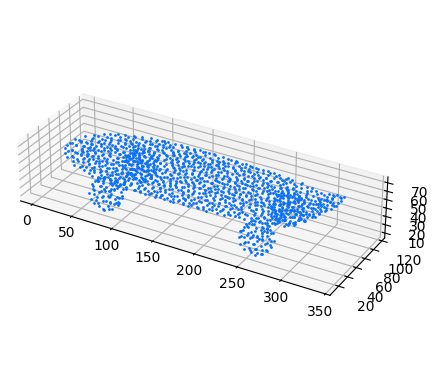

In [6]:
planner.visualize_point_cloud()

## Note

We use PyMeshLab library to sample points from mesh files, the sampling technique has randomness and may not generate identical results. From this point we use the original sampled point clouds that we used in the paper to reproduce the same results.

In [7]:
planner.load_point_cloud(os.path.join("assets", "dataset", "point_cloud", shapes["skateboard"]["point_cloud"]))

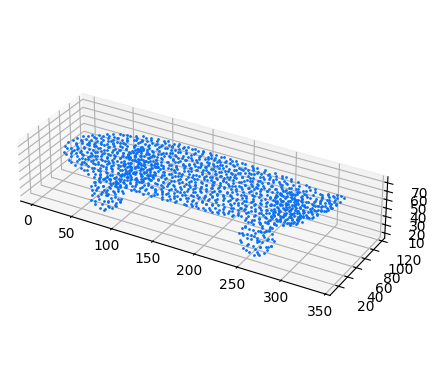

In [8]:
planner.visualize_point_cloud()

## Visualize Dead Reckoning
Simulate the point cloud with Dead Reckoning error.

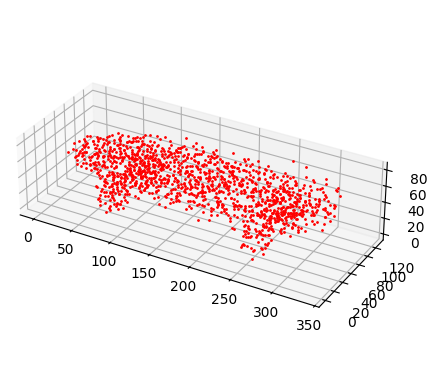

In [9]:
planner.visualize_deadreckoning(alpha=5)

## Compute Swarm-tree and FLS-tree

Planner group the FLSs into swarms of size G. Then computes two types trees, FLS-tree and Swarm-tree. FLS-tree is computed for each Swarm independently. It connects the FLSs within one swarm. Swarm-tree is a tree connecting Swarm centroids. We used 5, 10, 50, 150, and 200 as the values of G. Here we look at G=50. 

In [10]:
planner.compute_trees(swarm_size=50)
planner.save_trees()

## Add Dark Standby FLSs

After computing the FLS-tree and Swarm-tree there might be localizing FLSs that are outside the sweet range of their anchor FLS. Here Planner finds those FLSs and injects a dark standby FLS as an intermediate node. The standby FLS is placed in the intersection of the sweet range of the anchor and localizing FLSs. Planner save the corresponding files with `_sb` postfix.

In [11]:
planner.add_standbys()

Planner - INFO - Added 40 standby FLS
Planner - INFO - Saved stats and tree files as assets/skateboard_1372_50_spanning_2_sb*


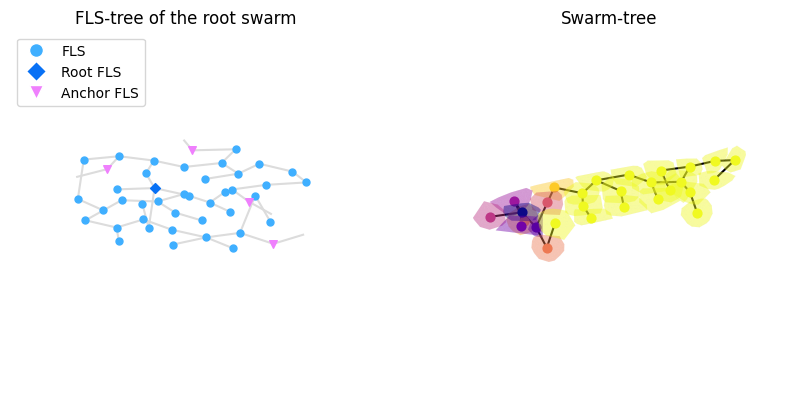

In [12]:
planner.visualize_trees()

## Compute FLS Mix
In this implementation Planner Assumes there are three FLS types with three different camera orientation, up, side, and down. Planner determines the type of each FLS based on the Swarm-tree and FLS-tree.

Planner - INFO - Total number of FLSs: 1412
Planner - INFO - Number (percentage) of each variant:
+Z:143 (10.13%), +X:1136 (80.45%), -Z:133 (9.42%)


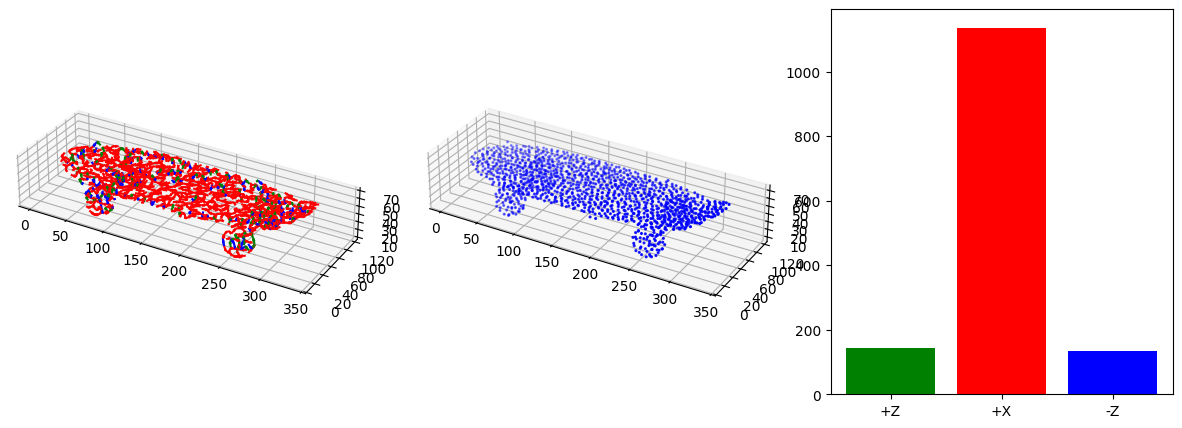

In [13]:
planner.compute_fls_mix()

# Decentralized Localization
Decentralized localization is the online component of the Swarical which is a multithreaded and multiprocess program. Its primary process runs `F` FLS processes. Each process emulates an FLS that represents a point in the input point cloud. FLS processes communicate with another through UDP messages util they are stopped by the primary process. FLS process consists of two thread, network thread to send and receive messages and handler thread to run the continues localization algorithm and take actions based on received messages. Ideally you 2x the number of physical processing cores 
The Decentralized Localization can be distributed across multiple nodes to facilitate emulating large point clouds. For this, in addition to the primary process, it utilized secondary processes that run on each node. The primary node and secondary nodes host roughly the same number of FLS processes each.
To begin with, we generate a small point cloud with points of a 4x4 grid and run the decentralized localization locally.

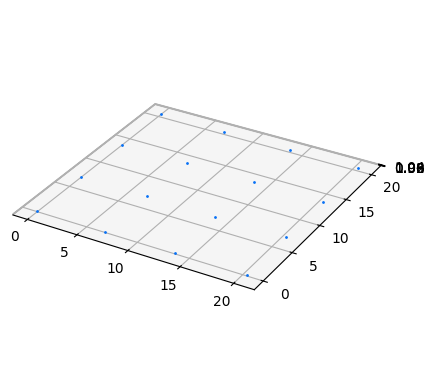

In [14]:
p = Planner()
p.set_fls_specs(
    fls_radius=0.03,
    fls_min_camera_range=0.068,
    fls_max_camera_range=0.136,
)
p.generate_grid_point_cloud(4)
p.compute_trees(swarm_size=4)
p.save_trees()
p.visualize_point_cloud()

Now, run the primary process. It will run for `config.DURATION` seconds and save the outputs in the results directory.

In [15]:
%run server.py

Primary - INFO - Results will be saved in results/grid4x4_16_4_spanning_2/Tspanning_2_v2/grid4x4_16_4_spanning_2_Sgrid4x4_16_4_spanning_2_D5_1743985241
Primary - INFO - Started 16 FLS processes on this none
Primary - INFO - Localizing...
Primary - INFO - Stopping FLS processes
Primary - INFO - Primary node finished executing


## Create Animation of the Localization Process

In [16]:
%run animation --help

usage: animation.py [-h] -i INPUT [-d DURATION] [-f FPS]
                    [--ticks-gap TICKS_GAP] [-s FLS_SIZE]

options:
  -h, --help            show this help message and exit
  -i INPUT, --input INPUT
                        input directory with charts.json
  -d DURATION, --duration DURATION
                        animation duration in seconds
  -f FPS, --fps FPS     frames per second
  --ticks-gap TICKS_GAP
                        ticks gap for the plot axes
  -s FLS_SIZE, --fls-size FLS_SIZE
                        FLS size


INFO:root:Animation saved to results/grid4x4_16_4_spanning_2/Tspanning_2_v2/grid4x4_16_4_spanning_2_Sgrid4x4_16_4_spanning_2_D5_1743982294/grid4x4_16_4_spanning_2_Sgrid4x4_16_4_spanning_2_D5_1743982294


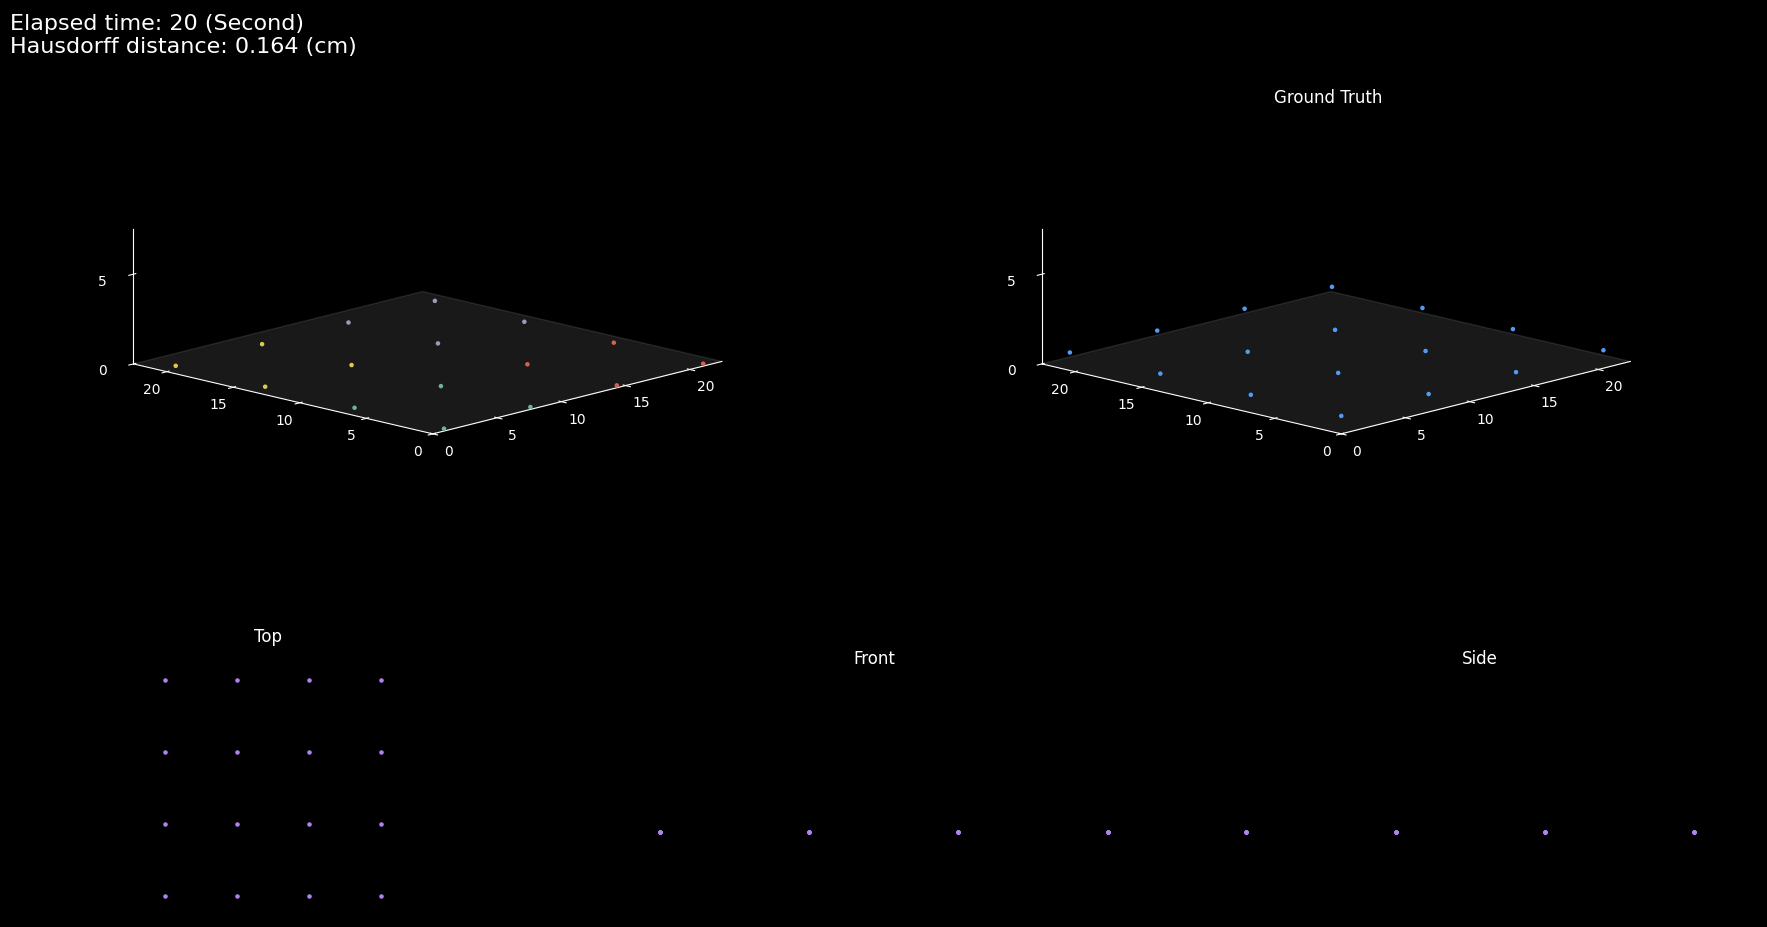

In [17]:
%run animation -i results/grid4x4_16_4_spanning_2/Tspanning_2_v2/grid4x4_16_4_spanning_2_Sgrid4x4_16_4_spanning_2_D5_1743982294